# Building a Multi-Agent Financial Analysis System using LangGraph

Build a multi-agent financial analysis system using LangGraph. This system utilizes the multi-agent supervisor pattern, where a supervisor agent orchestrates multiple specialized agents to accomplish complex tasks.

In addition to the supervisor, our system will include the following agents:

- Web Search Agent: Equipped with the Tavily web search tool to gather information from the web.
- Financial Analysis Agent: Uses the Alpha Vantage API to access stock market data.
- Code Agent: Has access to a Python REPL for generating code for data visualization.


### Imports and Setup
Let's start by importing the necessary libraries and setting up the environment.


In [1]:
# Imports
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
from langchain_community.utilities.alpha_vantage import AlphaVantageAPIWrapper
from langchain_experimental.tools import PythonREPLTool
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import AIMessage, HumanMessage, BaseMessage
from langgraph.graph import StateGraph, START, END
from langchain.agents import create_agent
from langgraph.checkpoint.memory import MemorySaver
import os
import re

from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict
from pydantic import BaseModel
import operator
import functools

# Load environment variables
from dotenv import load_dotenv
_ = load_dotenv()

# Helper function to check and reload environment variables
def check_env_vars(reload=False):
    """Check if required environment variables are set."""
    if reload:
        load_dotenv(override=True)
        print("✅ Environment variables reloaded!")
    
    required_vars = {
        "OPENROUTER_API_KEY": "OpenRouter API key for LLM access",
        "ALPHAVANTAGE_API_KEY": "Alpha Vantage API key for stock data",
        "TAVILY_API_KEY": "Tavily API key for web search (optional)"
    }
    
    print("📋 Environment Variables Status:\n")
    for var_name, description in required_vars.items():
        value = os.getenv(var_name)
        if value:
            # Show first and last 4 characters for security
            masked = f"{value[:4]}...{value[-4:]}" if len(value) > 8 else "***"
            print(f"✅ {var_name}: {masked} ({description})")
        else:
            print(f"❌ {var_name}: NOT SET ({description})")
    
    print("\n💡 Tip: If you just added variables to .env, run: check_env_vars(reload=True)")

# Check environment variables on import
check_env_vars()


c:\Users\ual-laptop\Downloads\AI Agent\Multi-Agent Financial Analysis System using LangGraph\.venv\Lib\site-packages\langchain_tavily\tavily_research.py:97: UserWarning: Field name "output_schema" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]
c:\Users\ual-laptop\Downloads\AI Agent\Multi-Agent Financial Analysis System using LangGraph\.venv\Lib\site-packages\langchain_tavily\tavily_research.py:97: UserWarning: Field name "stream" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]


📋 Environment Variables Status:

✅ OPENROUTER_API_KEY: sk-o...01c0 (OpenRouter API key for LLM access)
✅ ALPHAVANTAGE_API_KEY: NP2Q...9Z6C (Alpha Vantage API key for stock data)
✅ TAVILY_API_KEY: tvly...aitt (Tavily API key for web search (optional))

💡 Tip: If you just added variables to .env, run: check_env_vars(reload=True)


### Defining the Model

We will use the `openai/gpt-oss-120b` model.

In [ ]:
# # Define the LLM
# api_key = os.getenv("OPENROUTER_API_KEY")
# if not api_key:
#     raise ValueError("OPENROUTER_API_KEY environment variable is not set. Please set it in your .env file.")

# llm = ChatOpenAI(
#     model="openai/gpt-oss-120b:free",  
#     base_url="https://openrouter.ai/api/v1",
#     api_key=api_key,
#     temperature = 0,
#     max_tokens = 2000
# )

In [14]:
# For GROQ_ROUTER_API_KEY use
api_key = os.getenv("GROQ_API_KEY")
if not api_key:
   raise ValueError("GROQ_API_KEY environment variable is not set. Please set it in your .env file.")

llm = ChatOpenAI(
        model="openai/gpt-oss-120b",  # Groq model id
        base_url="https://api.groq.com/openai/v1",
        api_key=api_key,
        temperature=0,  # Groq converts 0 -> 1e-8 internally; OK
        max_tokens=2000,
    )


### Defining the Tools

#### 1. Current Date Tool
We define a simple tool to get the current date. This can be useful for time-based queries.

In [15]:
from langchain_core.tools import tool
from datetime import datetime

@tool
def get_current_date():
    """Returns the current date and time. Use this tool first for any time-based queries."""
    return f"The current date is: {datetime.now().strftime('%d %B %Y')}"

#### 2. Tavily Web Search Tool
We initialize the Tavily search tool for the Web Search Agent.


In [16]:
# Tavily Search Tool
# Note: Tavily API key should be set in environment variables if required
tavily_tool = TavilySearch(max_results=3)

#### 3. Alpha Vantage Tool
We create a custom tool for the Alpha Vantage API to fetch financial data.

In [17]:
# define custom tool for alpha vantage
from langchain_core.tools import BaseTool

class AlphaVantageQueryRun(BaseTool):
    """Tool that queries the Alpha Vantage API."""

    name: str = "alpha_vantage"
    description: str = (
        "A wrapper around Alpha Vantage API. "
        "Useful for getting financial information about stocks, "
        "forex, cryptocurrencies, and economic indicators. "
        "Input should be the name of the stock ticker."
    )
    api_wrapper: AlphaVantageAPIWrapper = AlphaVantageAPIWrapper()

    def _run(self, ticker: str) -> str:
        """Use the tool."""
        return self.api_wrapper._get_time_series_daily(ticker)

alpha_vantage_tool = AlphaVantageQueryRun()

#### 4. Python REPL Tool
We initialize the Python REPL tool for the Code Agent. Note: This tool can execute arbitrary code. Use with caution.

In [18]:
python_repl_tool = PythonREPLTool()

### Creating the Agents
We will create three agents, each with specific roles and tools.

#### 1. Web Search Agent

In [ ]:
# Web Search Agent
system_prompt = (
    "You are a web search agent specializing in financial information. "
    "Your role is to use web search tools to find current information and return comprehensive, well-structured answers. "
    "\n\nIMPORTANT:"
    "\n1. Search for the most recent and relevant information"
    "\n2. Synthesize information from multiple sources when available"
    "\n3. Provide clear, concise summaries with key points"
    "\n4. Cite sources or mention where information came from when relevant"
    "\n5. Focus on financial news, market trends, company performance, and related topics"
    "\n\nRESPONSE LENGTH:"
    "\n- Keep responses concise: 1-2 paragraphs is usually enough"
    "\n- Maximum 1000 words only if absolutely necessary for complex topics"
    "\n- Prioritize clarity and brevity over verbosity"
    "\n\nFormat your responses clearly with:"
    "- Main points or summary at the top"
    "- Supporting details below"
    "- Any relevant dates, numbers, or statistics"
)
web_search_agent = create_agent(llm, tools=[tavily_tool, get_current_date], system_prompt=system_prompt)

#### 2. Financial Analysis Agent

In [ ]:
# Financial Analysis Agent
system_prompt = (
    "You are a financial analysis agent. Your role is to use the Alpha Vantage tool to gather financial data and provide concise, informative answers. "
    "\n\nCRITICAL - ALWAYS USE THE TOOL:"
    "\n1. You MUST use the alpha_vantage tool for EVERY query - never ask for clarification"
    "\n2 If you see a ticker symbol (e.g., MSFT, AAPL), use it directly"
    "\n3. If the user says 'Microsoft', 'Apple', 'Tesla', etc., automatically convert to ticker and use the tool"
    "\n4. NEVER ask 'Could you let me know...' or 'What ticker...' - just extract and use the tool"
    "\n\nDATA PRESENTATION:"
    "\n1. Present data clearly in a structured format (tables, lists, or well-formatted text)"
    "\n2. Always format dates in human-readable format (e.g., 'December 12, 2025' instead of '2025-12-12')"
    "\n3. If asked about plots/charts/visualizations, provide the data clearly and state: 'I cannot create plots, but here is the data:'"
    "\n4. For visualization requests, include all necessary data (dates, prices, closing values) in a format that can be easily parsed"
    "\n\nRESPONSE LENGTH:"
    "\n- Keep responses concise: 1-2 paragraphs is usually enough"
    "\n- Maximum 1000 words only if absolutely necessary for complex data analysis"
    "\n- Focus on presenting data clearly, not lengthy explanations"
    "\n\nDo NOT:"
    "- Generate charts, plots, or visualizations (CodeAgent handles that)"
    "- Use vague or incomplete data"
    "- Skip important information like dates or prices"
    "- Be overly verbose - get to the point quickly"
)
financial_agent = create_agent(llm, tools=[alpha_vantage_tool, get_current_date], system_prompt=system_prompt)

#### 3. Code Agent

In [ ]:
# Code Agent
system_prompt = (
    "You are a visualization agent. Your role is to create visual representations of data using Python. "
    "Use the Python REPL tool provided to generate plots, charts, or other visualizations. "
    "\n\nIMPORTANT INSTRUCTIONS:"
    "\n1. Extract data from the conversation history - look for stock prices, dates, and financial data provided by FinancialAgent."
    "\n2. Parse the data (it may be in JSON, table, or text format) and convert it to Python data structures (lists, dictionaries, pandas DataFrames)."
    "\n3. Create appropriate visualizations using matplotlib (e.g., line plots for time series, bar charts for comparisons)."
    "\n4. Always include proper labels: title, x-axis label, y-axis label."
    "\n5. Format dates on x-axis if the data contains dates."
    "\n6. CRITICAL: Save the plot to a file instead of using plt.show(). "
    "\n   First create directory if needed: import os; os.makedirs('static/plots', exist_ok=True)"
    "\n   Then save: plt.savefig('static/plots/plot.png', dpi=150, bbox_inches='tight')"
    "\n   Finally close: plt.close()"
    "\n7. After saving, confirm completion with: 'Plot saved successfully. The visualization has been created.'"
    "\n\nRESPONSE LENGTH:"
    "\n- Keep text responses very brief: 1-2 sentences is usually enough"
    "\n- Maximum 1000 words only if absolutely necessary to explain complex visualization code"
    "\n- The visualization itself is the main output, not lengthy explanations"
    "\n\nDo NOT:"
    "- Perform data analysis or gather new information"
    "- Call APIs or fetch data (FinancialAgent already provided the data)"
    "- Generate multiple plots unless explicitly requested"
    "- Return without executing the visualization code"
    "- Write lengthy explanations - be concise"
)
code_agent = create_agent(llm, tools=[python_repl_tool], system_prompt=system_prompt)

#### 4. Supervisor Agent
The supervisor agent manages the workflow by deciding which agent should handle the next task.


In [ ]:
# Define team members
members = {
    "WebSearchAgent": "An agent that performs web searches to gather information",
    "FinancialAgent": "An agent that analyzes financial data using Alpha Vantage API to acquire stock market information.",
    "CodeAgent": "An agent that executes Python code and performs computations. Use this to generate plots and tables."
}

# Supervisor Prompt Template
system_prompt = (
    "You are a highly efficient supervisor managing a collaborative conversation between specialized agents:"
    "\n{members_description}"
    "\n\n=== YOUR ROLE ==="
    "\n1. Analyze the user's request and the ongoing conversation."
    "\n2. Determine which agent is best suited to handle the next task."
    "\n3. Ensure a logical flow and prevent unnecessary agent calls."
    "\n4. Detect task completion and respond with 'FINISH' when done."
    "\n\n=== DECISION RULES ==="
    "\n\n**VISUALIZATION REQUESTS (plot, chart, graph, visualize, draw):**"
    "\n1. Route to FinancialAgent FIRST to gather data"
    "\n2. After FinancialAgent provides data (look for: prices, dates, tables, or 'cannot create plots'), route to CodeAgent"
    "\n3. CRITICAL: After CodeAgent responds (even if it's just 'Plot generated' or similar), respond with FINISH immediately"
    "\n4. DO NOT route back to FinancialAgent if it already provided data"
    "\n5. DO NOT route to CodeAgent multiple times - one visualization per request"
    "\n\n**SIMPLE DATA QUERIES (price, stock value, closing price):**"
    "\n1. Route to FinancialAgent"
    "\n2. After FinancialAgent provides the answer, respond with FINISH immediately"
    "\n\n**NEWS/INFORMATION QUERIES (news, summary, latest information):**"
    "\n1. Route to WebSearchAgent"
    "\n2. After WebSearchAgent provides comprehensive answer, respond with FINISH"
    "\n\n**COMBINED QUERIES (news about stock performance):**"
    "\n1. Route to FinancialAgent for stock data (optional, if needed)"
    "\n2. Route to WebSearchAgent for news"
    "\n3. After WebSearchAgent responds, respond with FINISH"
    "\n\n=== COMPLETION DETECTION (When to FINISH) ==="
    "\nRespond with 'FINISH' when:"
    "\n✓ CodeAgent has been called and responded (even once) - visualization is complete"
    "\n✓ FinancialAgent provided a direct answer to a simple question (e.g., 'AAPL is $150')"
    "\n✓ WebSearchAgent provided comprehensive information"
    "\n✓ The same agent was called twice with similar responses (loop detected)"
    "\n✓ All user objectives are met"
    "\n\n=== ANTI-PATTERNS (What NOT to do) ==="
    "\n✗ DO NOT call CodeAgent multiple times for the same visualization request"
    "\n✗ DO NOT route back to FinancialAgent after it already provided data for a visualization"
    "\n✗ DO NOT continue routing if an agent already answered the question completely"
    "\n✗ DO NOT ignore completion signals (e.g., 'Plot generated', 'Visualization created')"
    "\n\n=== EXAMPLES ==="
    "\nUser: 'What was AAPL price?' → FinancialAgent → FINISH"
    "\nUser: 'Draw a plot of AAPL prices' → FinancialAgent → CodeAgent → FINISH"
    "\nUser: 'Latest news about Tesla' → WebSearchAgent → FINISH"
    "\nUser: 'Plot AAPL prices' → FinancialAgent → CodeAgent → FINISH (after CodeAgent responds)"
)

members_description = "\n".join([f"- {k}: {v}" for k, v in members.items()])

system_prompt = system_prompt.format(members_description=members_description)

# Possible options for the supervisor
options = ["FINISH"] + list(members.keys())

# Define the supervisor's output schema
class RouteResponse(BaseModel):
    """
    The supervisor's response to the user's request.
    """
    next: Literal["FINISH", "WebSearchAgent", "FinancialAgent", "CodeAgent"]

# Supervisor Prompt
supervisor_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        MessagesPlaceholder(variable_name="messages"),
        (
            "system",
            "Based on the conversation, who should act next? Choose one of: {options}",
        ),
    ]
).partial(options=str(options), members=", ".join([f"{k}: {v}" for k, v in members.items()]))

# Maximum iterations to prevent infinite loops (safety limit)
# This is per conversation thread - allows ~10-15 questions in a single conversation
# Loop detection handles most infinite loops before this limit is reached
MAX_ITERATIONS = 40

# Supervisor Agent Function
def supervisor_agent(state):
    # Check for maximum iterations (safety limit)
    messages = state.get("messages", [])
    agent_responses = [msg for msg in messages if isinstance(msg, AIMessage) and msg.name]
    if len(agent_responses) >= MAX_ITERATIONS:
        return {"next": "FINISH"}
    
    # Check for infinite loops: if the same agent has responded multiple times with identical/similar content
    if len(messages) >= 4:  # At least 2 agent responses
        # Get the last few agent messages (skip supervisor decisions and human messages)
        # Filter out messages without names to prevent errors
        agent_messages = [msg for msg in messages[-8:] if isinstance(msg, AIMessage) and hasattr(msg, 'name') and msg.name]
        
        if len(agent_messages) >= 2:
                # Check if the same agent responded multiple times consecutively
                last_agent = agent_messages[-1].name
                last_content = agent_messages[-1].content.strip()
                
                # Get all recent responses from the same agent (in reverse order)
                recent_same_agent_responses = [msg for msg in agent_messages if msg.name == last_agent]
                
                # Special handling for CodeAgent - if it's been called twice, likely generating duplicate plots
                if last_agent == "CodeAgent" and len(recent_same_agent_responses) >= 2:
                    # CodeAgent has been called multiple times, likely generating same plot
                    return {"next": "FINISH"}
                
                if len(recent_same_agent_responses) >= 2:
                # Get the last 2-3 responses from this agent
                contents = [msg.content.strip() for msg in recent_same_agent_responses[-3:]]
                
                # Check for exact matches first (most reliable indicator of a loop)
                if len(contents) >= 2:
                    # Check if last two responses are identical
                    if contents[-1] == contents[-2]:
                        # Force FINISH to break the loop
                        return {"next": "FINISH"}
                    
                    # Check if last three responses are identical (even more robust)
                    if len(contents) >= 3 and contents[-1] == contents[-2] == contents[-3]:
                        return {"next": "FINISH"}
                    
                    # Check for very high similarity (using normalized comparison)
                    # Normalize: remove extra whitespace and compare
                    def normalize(text):
                        return ' '.join(text.split())
                    
                    norm_contents = [normalize(c) for c in contents[-2:]]
                    if norm_contents[0] == norm_contents[1]:
                        return {"next": "FINISH"}
                    
                    # Check if responses are very similar (first 150 chars match and length difference < 5%)
                    if len(contents) >= 2:
                        c1, c2 = contents[-2], contents[-1]
                        if len(c1) > 50 and len(c2) > 50:  # Only check if responses are substantial
                            # Check if first 150 characters match (more robust than 100)
                            if c1[:150] == c2[:150]:
                                # Also check if overall length is very similar (within 5%)
                                # Prevent division by zero
                                max_len = max(len(c1), len(c2))
                                if max_len > 0:
                                    len_diff = abs(len(c1) - len(c2)) / max_len
                                    if len_diff < 0.05:  # Less than 5% difference
                                        return {"next": "FINISH"}
    
    # Check for visualization requests that need CodeAgent
    # (messages is already defined at the start of the function)
    if len(messages) >= 2:
        # Get the original user request
        user_messages = [msg for msg in messages if isinstance(msg, HumanMessage)]
        if user_messages:
            user_request = user_messages[0].content.lower()
            # Check if user asked for visualization
            viz_keywords = ['plot', 'chart', 'graph', 'visualize', 'visualization', 'draw', 'show me a graph', 'create a plot']
            is_viz_request = any(keyword in user_request for keyword in viz_keywords)
            
            if is_viz_request:
                # Check if FinancialAgent has already provided data
                agent_messages = [msg for msg in messages if isinstance(msg, AIMessage) and hasattr(msg, 'name') and msg.name]
                financial_agent_called = any(msg.name == "FinancialAgent" for msg in agent_messages)
                code_agent_called = any(msg.name == "CodeAgent" for msg in agent_messages)
                
                # If CodeAgent has already been called, check if it completed successfully
                if code_agent_called:
                    # Get the last CodeAgent message
                    code_agent_messages = [msg for msg in agent_messages if msg.name == "CodeAgent"]
                    if code_agent_messages:
                        last_code_response = code_agent_messages[-1].content.lower()
                        # Check if CodeAgent successfully generated a visualization
                        success_indicators = [
                            'plot', 'chart', 'graph', 'figure', 'visualization',
                            'matplotlib', 'plt.show()', 'display', 'created',
                            'generated', 'executed successfully'
                        ]
                        error_indicators = [
                            'error', 'failed', 'exception', 'traceback',
                            'cannot', "can't", 'unable'
                        ]
                        
                        # If CodeAgent response contains success indicators and no errors, FINISH
                        has_success = any(indicator in last_code_response for indicator in success_indicators)
                        has_error = any(indicator in last_code_response for indicator in error_indicators)
                        
                        if has_success and not has_error:
                            # CodeAgent has successfully generated visualization, FINISH
                            return {"next": "FINISH"}
                        # If there's an error, don't route back to CodeAgent (prevent infinite loop)
                        elif has_error:
                            return {"next": "FINISH"}
                
                # Route to CodeAgent only if FinancialAgent has provided data and CodeAgent hasn't been called yet
                if financial_agent_called and not code_agent_called:
                    # Check if the last agent was FinancialAgent
                    if agent_messages and agent_messages[-1].name == "FinancialAgent":
                        # Check if FinancialAgent provided data (not just an error)
                        last_content = agent_messages[-1].content.lower()
                        if any(indicator in last_content for indicator in ['price', 'date', 'closing', 'table', 'data', 'cannot create plots', "can't create"]):
                            return {"next": "CodeAgent"}
    
    try:
        # Try structured output first
        supervisor_chain = supervisor_prompt | llm.with_structured_output(RouteResponse)
        return supervisor_chain.invoke(state)
    except Exception as e:
        # Fallback: If structured output fails, try to parse plain text response
        try:
            # Get regular LLM response (not structured)
            regular_chain = supervisor_prompt | llm
            response = regular_chain.invoke(state)
            
            # Extract the content
            if hasattr(response, 'content'):
                content = response.content.strip()
            else:
                content = str(response).strip()
            
            # Try to parse the response - it might be just the agent name
            valid_options = ["FINISH", "WebSearchAgent", "FinancialAgent", "CodeAgent"]
            
            # Check if the response is a valid option
            for option in valid_options:
                if option.lower() in content.lower() or content == option:
                    return {"next": option}
            
            # Try to extract from JSON-like strings
            import json
            
            # Look for JSON pattern
            json_match = re.search(r'\{[^}]*"next"[^}]*\}', content)
            if json_match:
                try:
                    parsed = json.loads(json_match.group())
                    if "next" in parsed and parsed["next"] in valid_options:
                        return {"next": parsed["next"]}
                except:
                    pass
            
            # If we can't parse it, default to FINISH
            print(f"Supervisor: Could not parse response '{content}', defaulting to FINISH")
            return {"next": "FINISH"}
            
        except Exception as e2:
            # If all parsing fails, finish to prevent hanging
            print(f"Supervisor error: {e}")
            print(f"Fallback parsing also failed: {e2}")
            return {"next": "FINISH"}

### Constructing the Graph
We define the state, nodes, and edges for our graph.

In [23]:
# Define the state
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]  # Accept both HumanMessage and AIMessage
    next: str

In [24]:
# Helper Function for Agent Nodes
def agent_node(state, agent, name):
    try:
        # Validate state
        if not state or "messages" not in state:
            error_msg = f"{name} received invalid state."
            return {"messages": [AIMessage(content=error_msg, name=name)]}
        
        result = agent.invoke({"messages": state["messages"]})
        
        # Check if result is valid
        if not result or "messages" not in result or not result["messages"]:
            error_msg = f"{name} returned an empty or invalid response."
            return {"messages": [AIMessage(content=error_msg, name=name)]}
        
        # Clean the content: remove problematic Unicode characters like \u202f (narrow no-break space)
        content = result["messages"][-1].content
        
        # Handle None or empty content
        if not content:
            content = f"{name} completed but returned no content."
        
        # Replace narrow no-break space and other problematic Unicode spaces with regular space
        content = content.replace('\u202f', ' ')  # Narrow no-break space
        content = content.replace('\u2009', ' ')  # Thin space
        content = content.replace('\u00a0', ' ')   # Non-breaking space (convert to regular space)
        # Normalize multiple spaces to single space
        content = re.sub(r' +', ' ', content)
        
        # Add the agent's response to the conversation
        return {
            "messages": [AIMessage(content=content, name=name)]
        }
    except Exception as e:
        # Handle errors gracefully
        error_msg = f"{name} encountered an error: {str(e)}"
        print(f"Error in {name}: {e}")
        return {
            "messages": [AIMessage(content=error_msg, name=name)]
        }

#### Defining the Agent Nodes

In [25]:
# Web Search Node
web_search_node = functools.partial(agent_node, agent=web_search_agent, name="WebSearchAgent")

# Financial Analysis Node
financial_node = functools.partial(agent_node, agent=financial_agent, name="FinancialAgent")

# Code Agent Node
code_node = functools.partial(agent_node, agent=code_agent, name="CodeAgent")


#### Building the Graph

In [26]:
# Initialize the graph
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("WebSearchAgent", web_search_node)
workflow.add_node("FinancialAgent", financial_node)
workflow.add_node("CodeAgent", code_node)
workflow.add_node("Supervisor", supervisor_agent)

# Define edges
for member in members:
    # Each agent reports back to the supervisor
    workflow.add_edge(member, "Supervisor")

# Supervisor decides the next agent or to finish
conditional_map = {member: member for member in members}
conditional_map["FINISH"] = END
workflow.add_conditional_edges("Supervisor", lambda x: x["next"], conditional_map)

# Entry point
workflow.add_edge(START, "Supervisor")

# Compile the graph with memory checkpointing
memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)


#### Visualizing the Graph

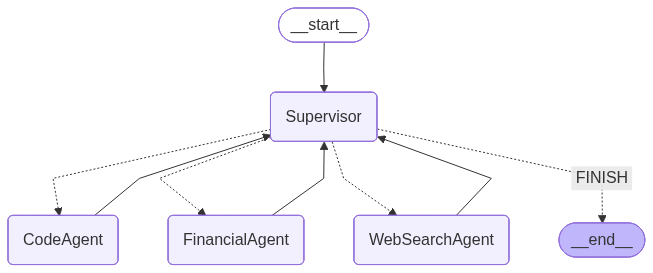

In [27]:
from IPython.display import display, Image

# Visualize the chatbot's workflow
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass  # Visualization requires additional dependencies

### Running the Multi-Agent System

We run the multi-agent system with different queries to demonstrate its capabilities.


In [28]:
# Helper Function to Process Events
from IPython.display import Markdown, display

def render_markdown(md_string):
    """Render markdown string using IPython display."""
    display(Markdown(md_string))

def process_event(event):
    """Process and display events from the graph execution."""
    if not event:
        return
    
    # Skip printing raw event dictionary - it's not user-friendly
    # Only process meaningful content
    
    # LangGraph events are dictionaries where keys are node names
    # and values are the state dictionaries (containing messages, next, etc.)
    # Example: {"Supervisor": {"messages": [...], "next": "FinancialAgent"}}
    
    # Iterate through each node's state in the event
    for node_name, node_state in event.items():
        if node_name == "__end__":
            continue
            
        if not isinstance(node_state, dict):
            continue
        
        # Process supervisor decisions
        if "next" in node_state:
            next_agent = node_state.get('next', 'Unknown')
            if next_agent == "FINISH":
                decision_msg = f"**✅ Supervisor Decision:** Task completed. Finishing execution."
            else:
                decision_msg = f"**🎯 Supervisor Decision:** Routing to **{next_agent}**"
            render_markdown(decision_msg)
            print()  # Add spacing
        
        # Process agent messages
        if "messages" in node_state and node_state["messages"]:
            try:
                # Get the last message from this node's state
                last_message = node_state["messages"][-1]
                
                # Get agent name (either from message.name or use node_name)
                agent_name = getattr(last_message, 'name', node_name)
                content = getattr(last_message, 'content', str(last_message))
                
                # Skip if this is a HumanMessage (user input)
                if hasattr(last_message, '__class__') and 'Human' in last_message.__class__.__name__:
                    continue
                
                # Format agent name as a header
                header = f"### 🤖 {agent_name}"
                render_markdown(header)
                
                # Render content as markdown
                render_markdown(content)
                print()  # Add spacing between messages
                
            except (IndexError, AttributeError, TypeError) as e:
                error_msg = f"**Error processing message event:** {str(e)}\n\n*Event structure: {type(event)}*"
                render_markdown(error_msg)
                
            except (IndexError, AttributeError, TypeError) as e:
                error_msg = f"**Error processing message event:** {str(e)}\n\n*Event structure: {type(event)}*"
                render_markdown(error_msg)
        elif "next" in event:
            next_agent = event.get('next', 'Unknown')
            if next_agent == "FINISH":
                decision_msg = f"**✅ Supervisor Decision:** Task completed. Finishing execution."
            else:
                decision_msg = f"**🎯 Supervisor Decision:** Routing to **{next_agent}**"
            render_markdown(decision_msg)
            print()  # Add spacing


#### Example 1: Fetching the Latest Closing Stock Price
User Request: "What was the last closing stock price of AAPL?"


In [29]:
# Be sure to use different thread_ids for different runs
config = {"configurable": {"thread_id": "1"}}

# Run the graph
events = graph.stream(
    {"messages": [HumanMessage(content="What was the last closing stock price of AAPL?")]},
    config=config
)

for event in events:
    process_event(event)


**🎯 Supervisor Decision:** Routing to **FinancialAgent**

### 🤖 FinancialAgent

The most recent daily data for Apple (AAPL) is for **January 5, 2026**, and the closing price on that day was **$267.26**.

**✅ Supervisor Decision:** Task completed. Finishing execution.

#### Example 2: Summarizing Latest News
User Request: "Summarize the latest news about Tesla's stock performance."


In [30]:
config = {"configurable": {"thread_id": "2"}}

# Run the graph
events = graph.stream(
    {"messages": [HumanMessage(content="Summarize the latest news about Tesla's stock performance.")]},
    config=config
)

for event in events:
    process_event(event)


**🎯 Supervisor Decision:** Routing to **WebSearchAgent**

### 🤖 WebSearchAgent

**Tesla (TSLA) – Stock‑Market Snapshot (latest week, early January 2026)** 

| Metric / Event | What happened | Market reaction | Source |
|----------------|---------------|----------------|--------|
| **Q4 2025 vehicle deliveries** | 418,227 units shipped – **16 % lower** than Q4 2024 and about 5 % below the Street consensus of ~423 k. Production was 434,358 units. | Shares **rose ~2 %** after the release (the dip was offset by the beat on production and a $1 bn share‑buyback by Elon Musk in September). The stock was trading around **$447‑$450** in mid‑morning trade. | 【2†L1-L9】【2†L10-L14】 |
| **Quarter‑over‑quarter momentum** | After a **40 % rally in Q3 2025**, the stock slipped in Q4 but still finished 2025 **≈16 % higher** year‑to‑date. | The modest Q4 gain kept the stock near its all‑time highs, but analysts note the delivery slowdown could pressure the near‑term trend. | 【1†L1-L4】【1†L5-L8】 |
| **Energy‑storage business** | Deployed **14.2 GWh** of battery‑energy‑storage systems in Q4 2025 (up from 12.5 GWh in Q3). | Positive backdrop for revenue diversification; analysts remain “bullish on long‑term growth” despite the delivery dip. | 【1†L9-L12】 |
| **Competitive pressure – Nvidia** | Nvidia’s latest AI‑driven self‑driving platform (dubbed a “ChatGPT moment”) is gaining market share, prompting a **2.8 % drop** in Tesla’s share price in early‑January coverage. | The article frames Nvidia as a new rival to Tesla’s Full‑Self‑Driving (FSD) stack and highlights Tesla’s upcoming **Cybercab robo‑taxi** program slated for 2026. | 【3†L1-L8】 |
| **Analyst sentiment** | While the stock has taken a short‑term hit, most analysts continue to view Tesla as a **long‑term growth play**, citing its brand, technology lead and expanding energy‑storage line. | No major downgrades yet; price target revisions are modest. | 【4†L1-L4】 |
| **Key upcoming catalysts** | • **Full‑year 2025 earnings release (late‑January)** – investors will watch guidance on 2026 deliveries and margins. <br>• **Cybercab robo‑taxi rollout** in 2026 – could open a new revenue stream. <br>• **Nvidia’s self‑driving AI** – potential impact on FSD adoption and pricing. | Market is awaiting the earnings call; volatility expected around guidance and any updates on the robo‑taxi program. | (derived from above sources) |

### Bottom line
- **Short‑term:** Tesla’s stock is hovering in the **$445‑$455** range after a modest Q4 earnings beat but a notable drop in vehicle deliveries. The share price dipped **≈2‑3 %** on news of Nvidia’s AI‑driven self‑driving push, underscoring heightened competition in autonomous‑driving technology.
- **Medium‑term:** The **energy‑storage segment** continues to grow, and the **Cybercab robo‑taxi** plan for 2026 offers a fresh growth narrative. Analyst consensus remains **bullish on the long‑term outlook**, with the next earnings report (late Jan 2026) likely to set the tone for the coming months. 

*All figures are from publicly‑available news reports dated January 1‑6 2026.*

**✅ Supervisor Decision:** Task completed. Finishing execution.

#### Example 3: Generating a Stock Price Plot
User Request: "Draw a plot of the closing stock prices of AAPL over the last week, with the x-axis being the closing dates."


**🎯 Supervisor Decision:** Routing to **FinancialAgent**

### 🤖 FinancialAgent

**Apple Inc. (AAPL) – Closing Prices for the Most Recent Trading Week**

| Date (human‑readable) | Closing Price (USD) |
|-----------------------|---------------------|
| January 5, 2026 | **267.26** |
| January 2, 2026 | **271.01** |
| December 31, 2025 | **271.86** |
| December 30, 2025 | **273.08** |
| December 29, 2025 | **273.76** |

### Quick Takeaway
- **Trend:** The stock has been on a downward trajectory over the past five trading days, slipping from **$273.76** on December 29, 2025 to **$267.26** on January 5, 2026 — a decline of roughly **2.4 %**.
- **Potential Drivers:** The drop may reflect end‑of‑year profit‑taking, broader market sentiment, or company‑specific news released after the close on December 30. Further context (e.g., earnings releases, macro‑economic data) would be needed to pinpoint the cause.
- **Outlook:** If the recent dip is a short‑term correction, the price could stabilize near the $270‑$275 range. Conversely, continued weakness might signal a deeper pullback, especially if broader market pressures persist. Monitoring upcoming earnings guidance and any macro‑economic updates will be key.

**🎯 Supervisor Decision:** Routing to **CodeAgent**

### 🤖 CodeAgent

I’m ready to create the plot, but I need the actual closing‑price data for AAPL over the last week. Could you please provide the dates (or date strings) and the corresponding closing prices? Once I have that information, I’ll generate the requested visualization for you.

**🎯 Supervisor Decision:** Routing to **CodeAgent**

Python REPL can execute arbitrary code. Use with caution.


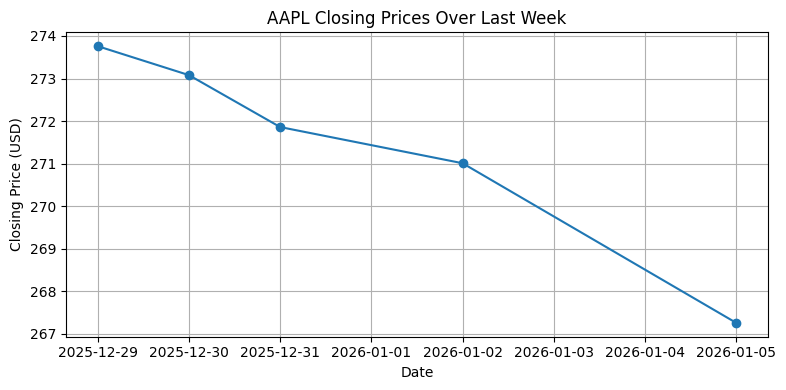

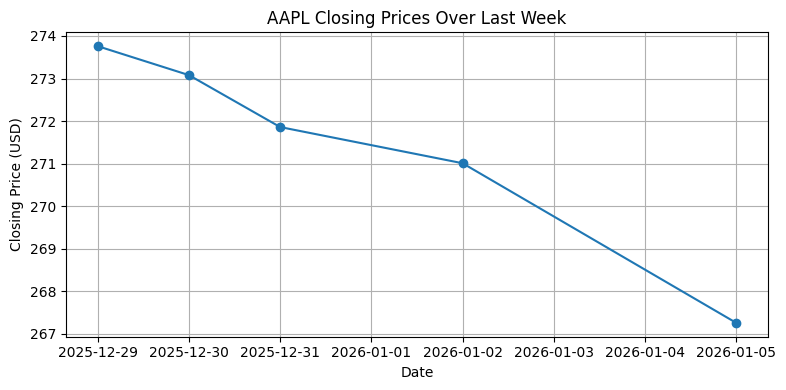

Error in CodeAgent: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-120b` in organization `org_01ke8hqskfebh92yfgem384f1f` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 26953, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


### 🤖 CodeAgent

CodeAgent encountered an error: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-120b` in organization `org_01ke8hqskfebh92yfgem384f1f` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 26953, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

**🎯 Supervisor Decision:** Routing to **CodeAgent**

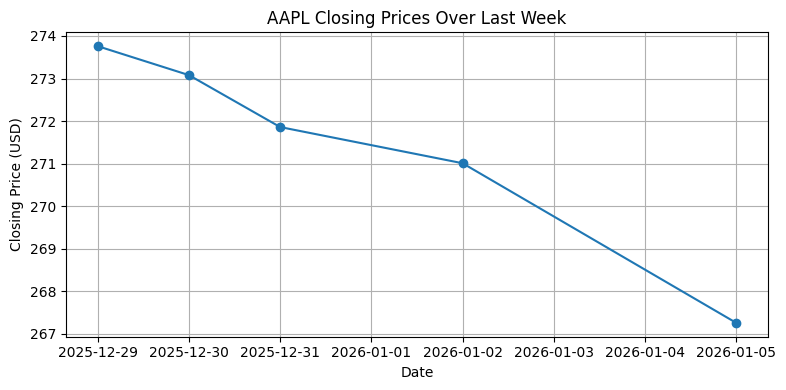

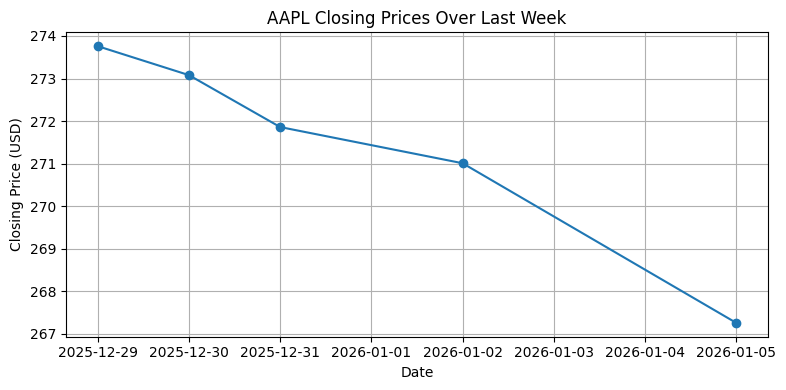

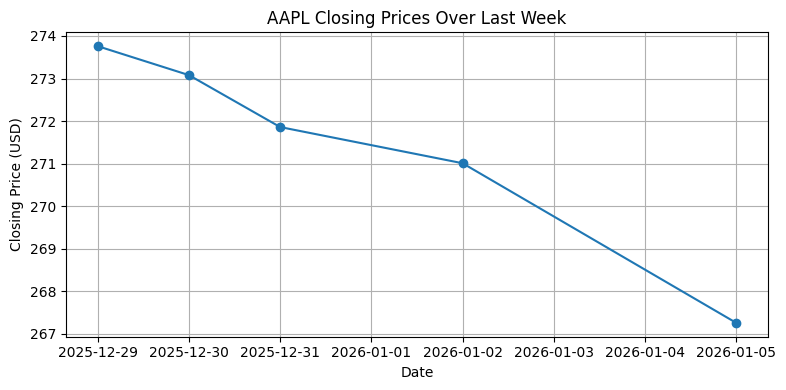

### 🤖 CodeAgent

Here is the plot of AAPL’s closing prices over the most recent trading week:

![AAPL Closing Prices Over Last Week](attachment://output.png)

**✅ Supervisor Decision:** Task completed. Finishing execution.

In [31]:
config = {"configurable": {"thread_id": "3"}}

# Run the graph
events = graph.stream(
    {"messages": [HumanMessage(content="Draw a plot of the closing stock prices of AAPL over the last week, with the x axis being the closing dates.")]},
    config=config
)

for event in events:
    process_event(event)

NOTE: Couple of things that I consider as future scope: 

- Changing the stock ticker symbol to analyze a different company.
- Modifying the system prompts for each agent to adjust behavior and task focus.
- Adding external APIs like Yahoo Finance or Reuters for broader financial data.
- Adjusting the supervisor to add reflection steps and introduce multiple iterations for quality improvement.
- Improving the output format to enhance user experience.